# Shap Interpretation

**Purpose**: Shap Interpretation of the given data

**Input**: XGB Model, X, y data

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import joblib
import json
from src.features.engineering import (
    create_features,
    create_gap_label,
    prepare_model_data,
)
from src.config import RANDOM_SEED, TEST_SIZE
import shap

In [4]:
PROJECT_DIR = Path.cwd().parent.parent
DATA_FILE = PROJECT_DIR / "data" / "processed" / "ochota_stops_with_amenities.csv"
MODELS_DIR = PROJECT_DIR / "models"
SAVE_DIR = PROJECT_DIR / "artifacts" / "figures" / "notebook03"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
df = pd.read_csv(DATA_FILE)

df = create_features(df)
df = create_gap_label(df)

X, y = prepare_model_data(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)


In [6]:
model = joblib.load(MODELS_DIR / "xgboost_gap_model.joblib")
with open(MODELS_DIR / "xgboost_gap_model.json") as f:
    metadata = json.load(f)

In [7]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

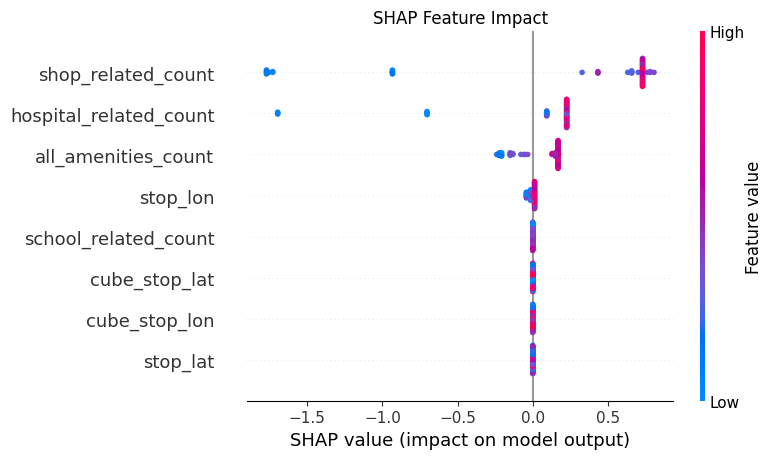

In [17]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Impact')
plt.tight_layout()
plt.savefig(SAVE_DIR / "shap_feature_impact.png")
plt.show()